# Tutorial 2d: OPD, PSF and MTF Calculations

Consolidating Optical Path Difference (OPD), Point Spread Function (PSF), Modulation Transfer Function (MTF), and Zernike decomposition wavefront fitting.


### June 2024

This tutorial demonstrates how to compute the optical path difference in the exit pupil and the various ways to plot it.

In [1]:
from optiland import wavefront
from optiland.samples.eyepieces import EyepieceErfle

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

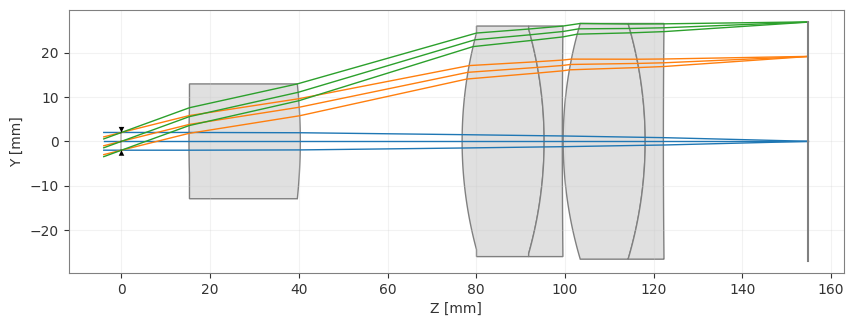

In [2]:
lens = EyepieceErfle()
lens.draw()

First, we compute the OPD fans for each field and wavelength.

(<Figure size 1000x900 with 6 Axes>,
 array([[<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_y$', ylabel='Wavefront Error (waves)'>,
         <Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='$P_x$', ylabel='Wavefront Error (waves)'>],
        [<Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_y$', ylabel='Wavefront Error (waves)'>,
         <Axes: title={'center': 'Hx: 0.000, Hy: 0.700'}, xlabel='$P_x$', ylabel='Wavefront Error (waves)'>],
        [<Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_y$', ylabel='Wavefront Error (waves)'>,
         <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='$P_x$', ylabel='Wavefront Error (waves)'>]],
       dtype=object))

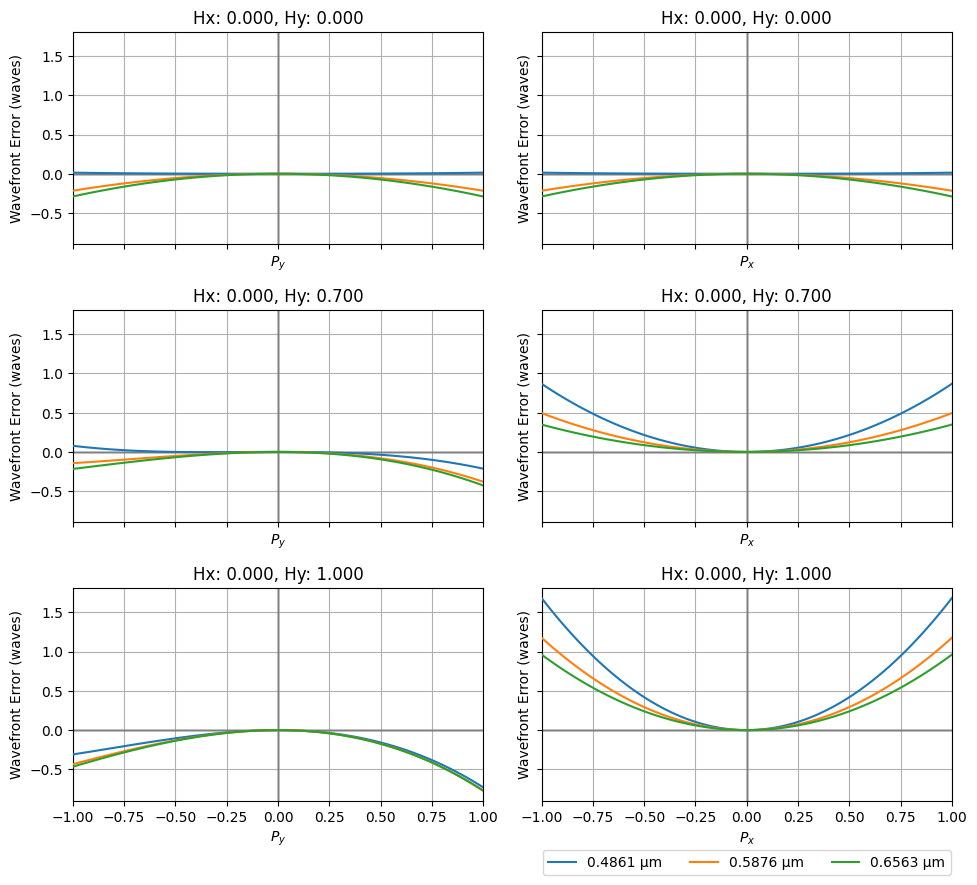

In [3]:
opd_fan = wavefront.OPDFan(lens)
opd_fan.view()

Next, we compute the wavefront map for each field and demonstrate different ways of plotting.

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'OPD Map: RMS=0.134 waves'}, xlabel='Pupil X', ylabel='Pupil Y'>)

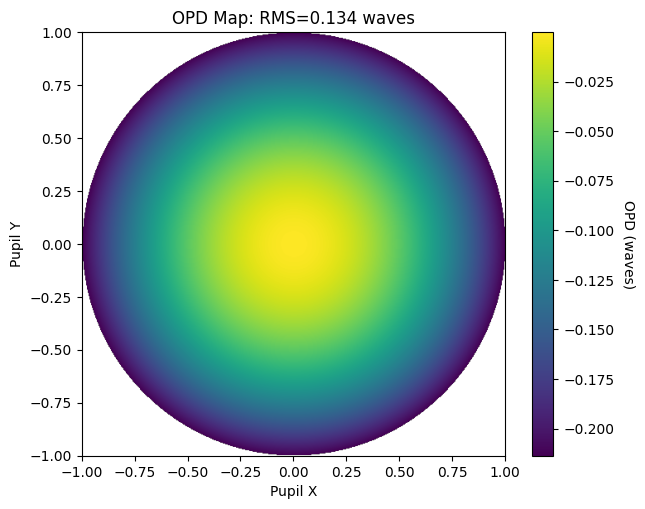

In [4]:
opd = wavefront.OPD(lens, field=(0, 0), wavelength=0.5876)
opd.view(projection="2d", num_points=512)

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'OPD Map: RMS=0.185 waves'}, xlabel='Pupil X', ylabel='Pupil Y'>)

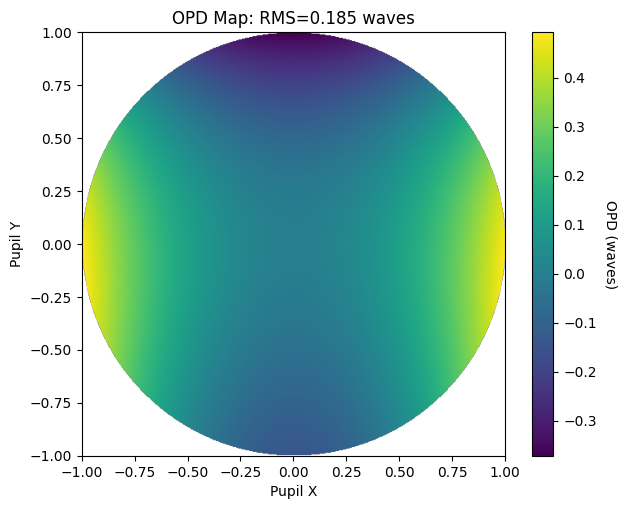

In [5]:
opd = wavefront.OPD(lens, field=(0, 0.7), wavelength=0.5876)
opd.view(projection="2d", num_points=512)

(<Figure size 700x550 with 2 Axes>,
 <Axes3D: title={'center': 'OPD Map: RMS=0.430 waves'}, xlabel='Pupil X', ylabel='Pupil Y', zlabel='OPD (waves)'>)

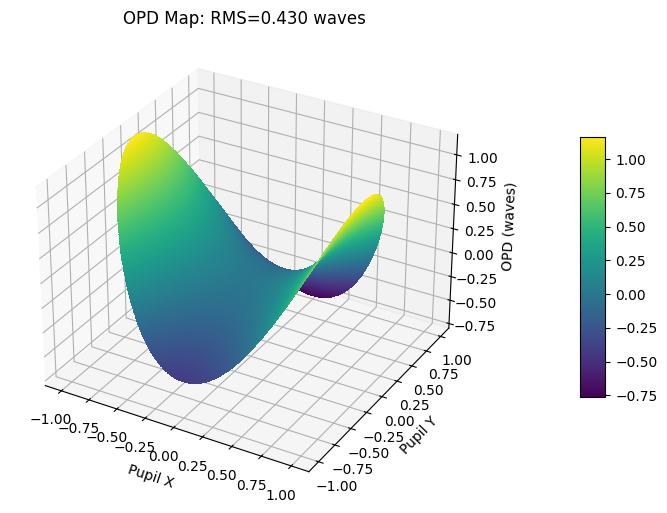

In [6]:
opd = wavefront.OPD(lens, field=(0, 1.0), wavelength=0.5876)
opd.view(projection="3d", num_points=512)


---
## Part 2: PSF & MTF Calculation



### June 2024

This tutorial shows how to calculate the point spread function (PSF) and modulation transfer function (MTF) of a lens.

In [1]:
from optiland import mtf, psf
from optiland.samples.objectives import CookeTriplet

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

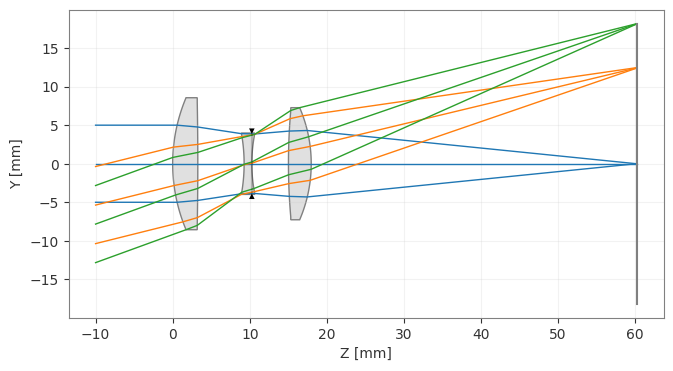

In [2]:
lens = CookeTriplet()
lens.draw()

We first compute the PSF using the FFT-based approach. We demonstrate various ways to generate and plot the PSF.

C:\Users\kdani\AppData\Local\Temp\ipykernel_30580\3512864652.py:2: UserWarning: The PSF view has a high oversampling factor (5.57). Results may be inaccurate.
  lens_psf.view(projection="3d", num_points=256)


(<Figure size 700x550 with 2 Axes>,
 <Axes3D: title={'center': 'ScalarFFT PSF'}, xlabel='X (µm)', ylabel='Y (µm)', zlabel='Relative Intensity (%)'>)

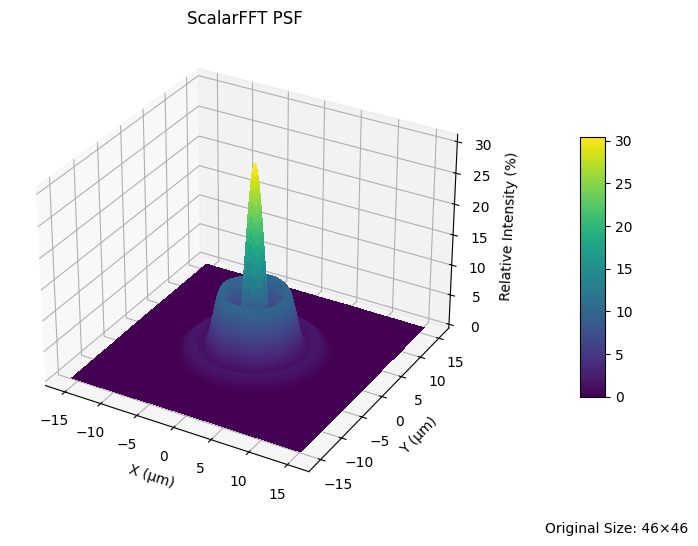

In [3]:
lens_psf = psf.FFTPSF(lens, field=(0, 0), wavelength=0.55)
lens_psf.view(projection="3d", num_points=256)

In [4]:
print(f"Strehl Ratio: {lens_psf.strehl_ratio():.3f}")

Strehl Ratio: 0.306


C:\Users\kdani\AppData\Local\Temp\ipykernel_30580\3051880103.py:2: UserWarning: The PSF view has a high oversampling factor (4.65). Results may be inaccurate.
  lens_psf.view(num_points=512)


(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'ScalarFFT PSF'}, xlabel='X (µm)', ylabel='Y (µm)'>)

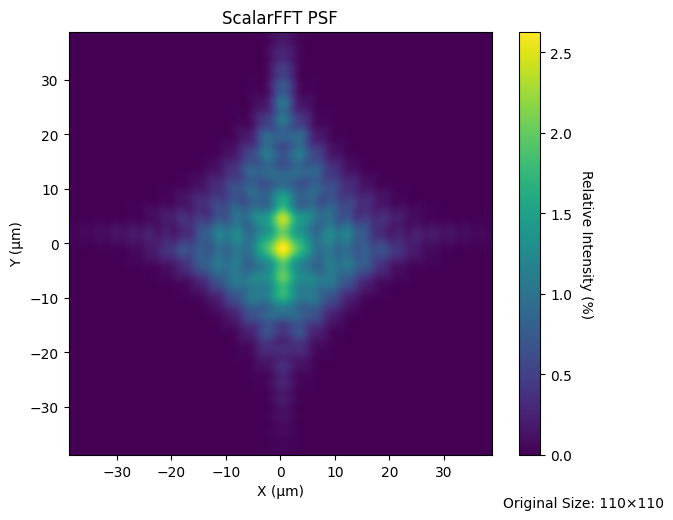

In [5]:
lens_psf = psf.FFTPSF(lens, field=(0, 0.7), wavelength=0.55)
lens_psf.view(num_points=512)

C:\Users\kdani\AppData\Local\Temp\ipykernel_30580\48181633.py:2: UserWarning: The PSF view has a high oversampling factor (3.46). Results may be inaccurate.
  lens_psf.view(projection="2d", num_points=256)


(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'ScalarFFT PSF'}, xlabel='X (µm)', ylabel='Y (µm)'>)

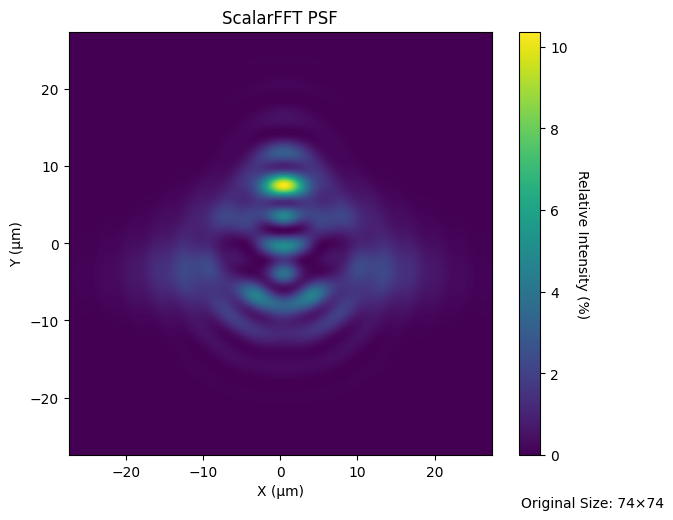

In [6]:
lens_psf = psf.FFTPSF(lens, field=(0, 1.0), wavelength=0.55)
lens_psf.view(projection="2d", num_points=256)

We can also generate the PSF using direct Huygens-Fresnel integration. This is referred to as the "Huygens PSF".

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'ScalarHuygens PSF'}, xlabel='X (µm)', ylabel='Y (µm)'>)

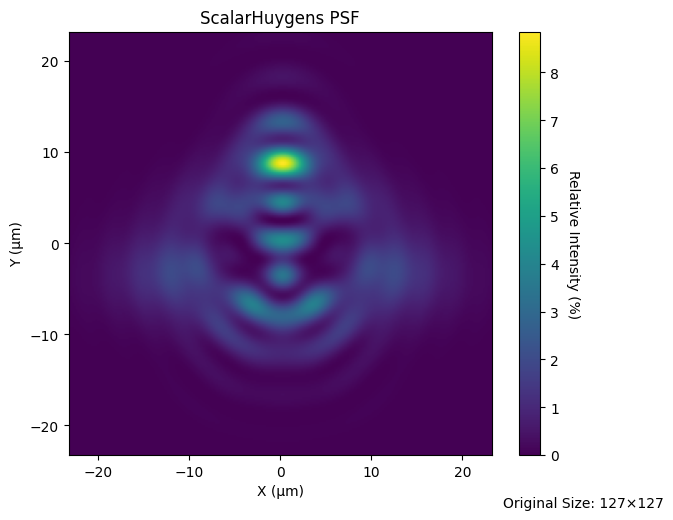

In [7]:
lens_huygens_psf = psf.HuygensPSF(lens, field=(0, 1.0), wavelength=0.55)
lens_huygens_psf.view(projection="2d", num_points=256)

Now, we generate the geometric MTF, which uses only ray intersection locations on the image plane and ignores diffraction. The geometric MTF is a reasonable approximation when the lens is far from the diffraction limit.

As is standard, the geometric MTF is scaled based on the diffraction-limited MTF curve. This assures that the geometric MTF cannot show performance better than the diffraction limit.

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Frequency (cycles/mm)', ylabel='Modulation'>)

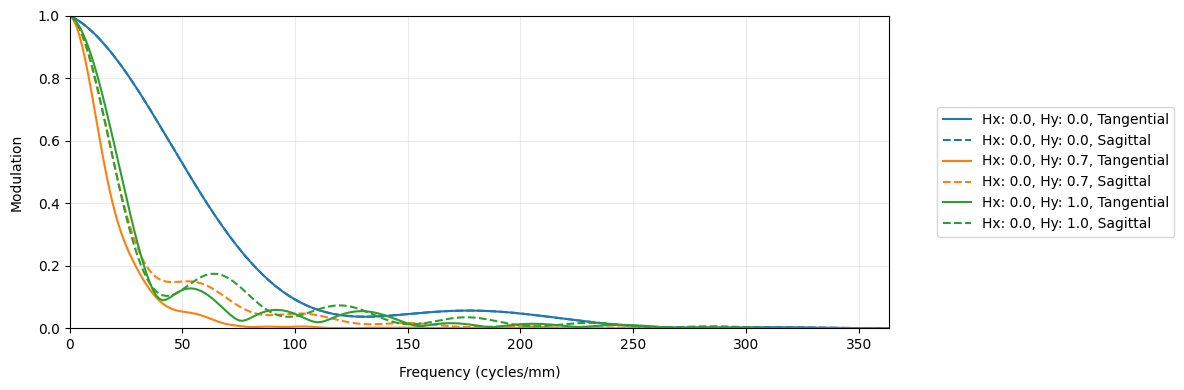

In [8]:
geo_mtf = mtf.GeometricMTF(lens)
geo_mtf.view()

Finally, we show the standard FFT-based MTF.

(<Figure size 1200x400 with 1 Axes>,
 <Axes: xlabel='Frequency (cycles/mm)', ylabel='Modulation'>)

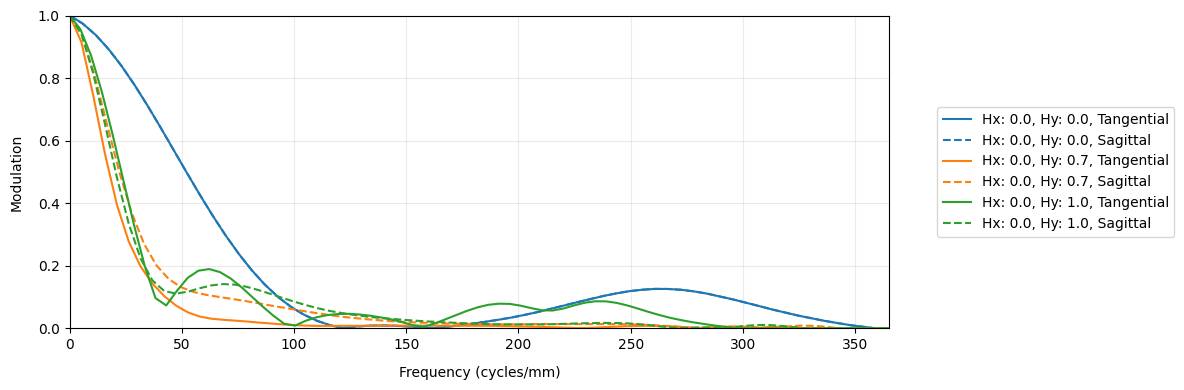

In [9]:
lens_mtf = mtf.FFTMTF(lens)
lens_mtf.view()


---
## Part 3: Zernike Decomposition



### June 2024

This tutorial shows how to decompose the pupil using various Zernike types. Namely, we use "standard", "fringe", and "Noll" Zernike indices.

In [1]:
import matplotlib.pyplot as plt

from optiland import wavefront
from optiland.samples.eyepieces import EyepieceErfle

(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

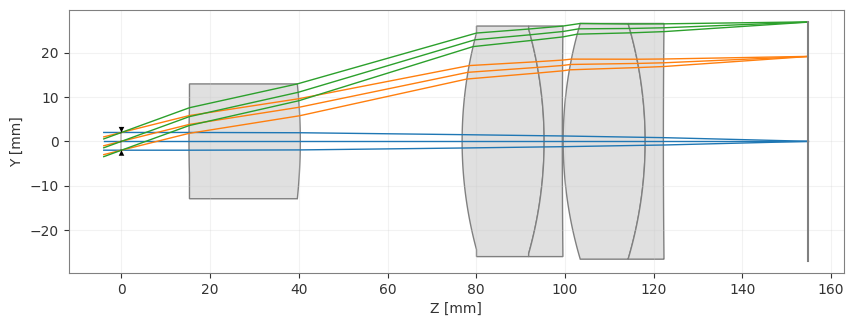

In [2]:
lens = EyepieceErfle()
lens.draw()

First, we'll view the wavefront.

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'OPD Map: RMS=0.095 waves'}, xlabel='Pupil X', ylabel='Pupil Y'>)

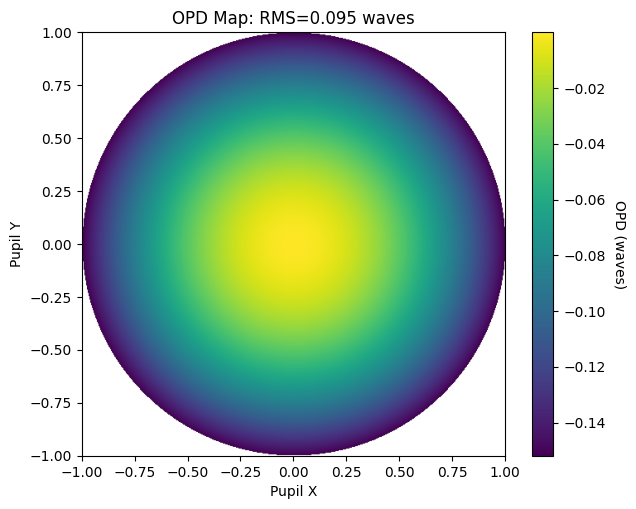

In [3]:
opd = wavefront.OPD(lens, field=(0, 0), wavelength=0.55)
opd.view(projection="2d", num_points=512)

We'll then find the Zernike coefficients of the wavefront.

In [4]:
zernike_standard = wavefront.ZernikeOPD(
    lens,
    field=(0, 0),
    wavelength=0.55,
    zernike_type="standard",
    num_terms=37,
)

Let's view the Zernike fit and compare it to the nominal OPD map.

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'Zernike Standard Fit'}, xlabel='Pupil X', ylabel='Pupil Y'>)

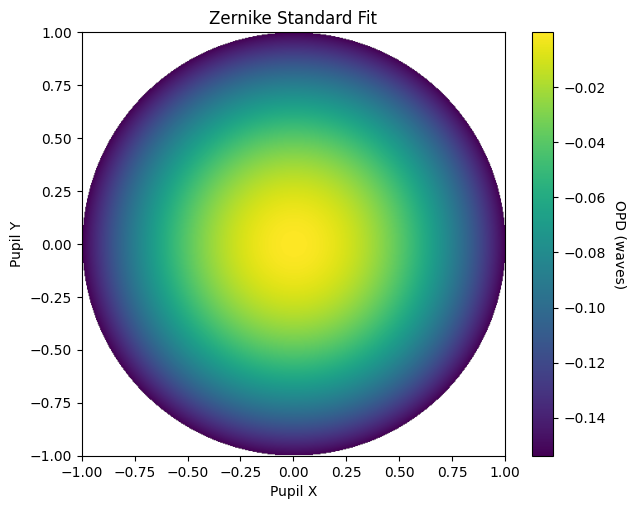

In [5]:
zernike_standard.view(projection="2d", num_points=512)

Qualitatively, we can see the Zernike fit well-represents the OPD map.

Let's see what the actual coefficients look like:

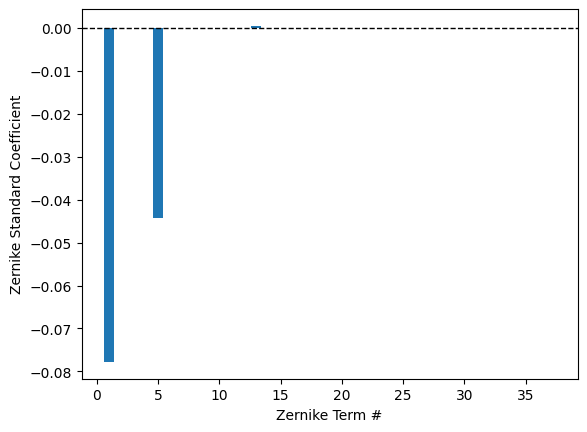

In [6]:
plt.bar(range(1, 38), zernike_standard.coeffs)
plt.axhline(color="k", linewidth=1, linestyle="--")
plt.xlabel("Zernike Term #")
plt.ylabel("Zernike Standard Coefficient")
plt.show()

Let's decompose the wavefront using Zernike fringe indices and Zernike Noll indices. We'll use the field point at (0, 1).

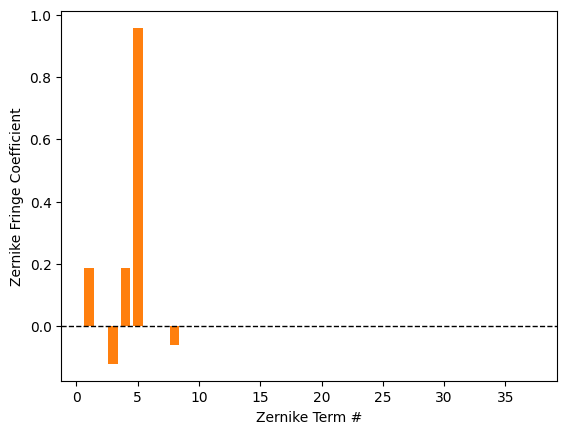

In [7]:
zernike_fringe = wavefront.ZernikeOPD(
    lens,
    field=(0, 1),
    wavelength=0.55,
    zernike_type="fringe",
    num_terms=37,
)

plt.bar(range(1, 38), zernike_fringe.coeffs, color="C1")
plt.axhline(color="k", linewidth=1, linestyle="--")
plt.xlabel("Zernike Term #")
plt.ylabel("Zernike Fringe Coefficient")
plt.show()

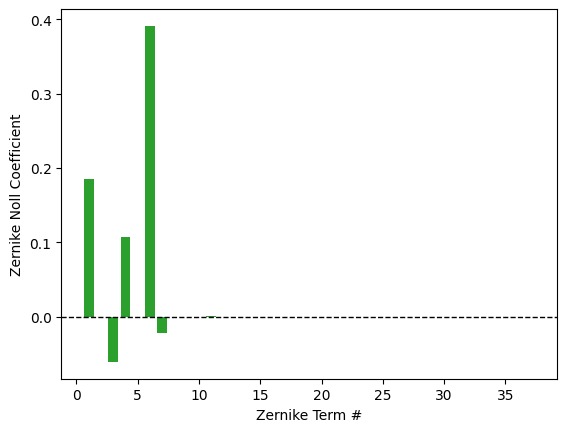

In [8]:
zernike_noll = wavefront.ZernikeOPD(
    lens,
    field=(0, 1),
    wavelength=0.55,
    zernike_type="noll",
    num_terms=37,
)

plt.bar(range(1, 38), zernike_noll.coeffs, color="C2")
plt.axhline(color="k", linewidth=1, linestyle="--")
plt.xlabel("Zernike Term #")
plt.ylabel("Zernike Noll Coefficient")
plt.show()

Or, if we just want to read off the coefficients, we can print them. Let's only use 9 terms in this case:

In [9]:
zernike = wavefront.ZernikeOPD(lens, (0, 1), 0.55, zernike_type="noll", num_terms=9)

for k in range(len(zernike.coeffs)):
    print(f"Z{k + 1}: {zernike.coeffs[k]:.8f}")

Z1: 0.18585891
Z2: -0.00000000
Z3: -0.06086925
Z4: 0.10781267
Z5: 0.00000000
Z6: 0.39115859
Z7: -0.02152073
Z8: -0.00000000
Z9: 0.00002531
